# 福州大学数学与统计学院

## 2025-2026 学年第 2 学期《数据分析与可视化》期末考试答题模板

- 考试时间：2026年06月24日 14:00-17:30
- 考试地点：旗山东2-102
- 考试人数：44 人

> 文件命名建议：`学号_姓名_期末考试.ipynb`

请在提交前从头到尾顺序运行一次 Notebook，确认所有代码无报错，图表和结果完整显示。

## 教师评分区

> 本区域由教师评分时填写，学生不要删除。

| 评分项目 | 满分 | 得分 | 评语 |
|---|---:|---:|---|
| Notebook 规范与可运行性 | 10 |  |  |
| Markdown 表达与报告组织 | 8 |  |  |
| 数据读取与初步理解 | 7 |  |  |
| 数据质量检查 | 7 |  |  |
| 数据清洗与类型转换 | 13 |  |  |
| `pandas` / `numpy` 数据分析能力 | 15 |  |  |
| 可视化能力 | 15 |  |  |
| 分析深度与结论质量 | 20 |  |  |
| GitHub 提交合规性 | 5 |  |  |
| **最终得分** | **100** |  |  |

## 学生信息

- 专业：经济统计学
- 学号：032402107
- 姓名：李思旖
- GitHub 仓库链接：
- 数据文件：`ershoufang_list.csv`

# 福州二手房数据分析

## 1. 摘要

本报告基于 `ershoufang_list.csv` 中的福州二手房挂牌房源数据，对福州二手房市场的供给分布、价格水平、面积结构、房龄差异、楼层差异、户型结构和总价分层进行综合分析。原始数据共包含 **11856 条房源记录、18 个字段**，字段既包括市区、标题、户型、方位、楼层、时间、所属小区等文本信息，也包括面积、总价、均价等带有单位符号的价格与规模信息。为了提高分析的可靠性，本报告没有直接依赖数据中已有的数值列，而是从 `面积`、`总价`、`均价`、`时间`、`户型` 和 `楼层` 等原始文本字段中重新提取面积、总价、均价、建造年份、室厅卫数量、楼层位置和总楼层数，并对缺失值、重复值、单位字符、文本空格和异常高低值进行检查。

在清洗策略上，本报告遵循“保留市场信息、剔除不可分析记录”的原则：对于价格缺失的少量记录，仅在价格相关分析中剔除；对于大面积、高总价、高单价等极端房源，不简单认定为错误值，而是将其视为高端或特殊房源的一部分保留在数据中；在部分散点图中仅通过分位数范围控制展示尺度，避免少量豪宅房源压缩主体房源的图形表达。清洗后，价格与面积均完整且可用于分析的有效样本为 **11830 条**。

分析结果显示：第一，福州二手房挂牌供给高度集中，晋安与仓山两个市区合计占有效样本的约七成，是样本中最主要的供给区域；鼓楼、台江虽然房源量不及晋安、仓山，但单价中位数较高，体现出中心区资源溢价。第二，福州二手房均价分布呈右偏特征，主体房源集中在约 1.5 万—2.5 万元/㎡区间，少量高单价房源显著拉高均值。第三，面积与总价之间存在明显正相关，但相关关系并非单纯线性，单价、区位和户型品质会改变同等面积房源的总价水平。第四，不同房龄房源的价格差异并不表现为“越新越贵”的简单关系，2 年内新房源的中位均价反而较低，说明新房源可能更多分布在外围或新开发板块，而老房源可能因位于核心城区而保持较高单价。第五，面积段和户型结构共同塑造市场层级，60—120㎡房源构成主流刚需与改善市场，150㎡以上房源数量较少但总价与单价均明显抬升，体现出高端改善或稀缺资源属性。整体来看，福州二手房市场呈现出“供给集中在外围扩张区、价格高点集中在核心城区、主流成交想象集中在中小面积和中等总价区间”的结构性特征。

## 2. 数据读取与分析目标

### 2.1 数据来源与字段含义

本次分析使用考试提供的 `ershoufang_list.csv` 文件。数据主题为福州二手房挂牌房源，字段包括房源编号、城市、市区、标题、户型、面积、方位、楼层、建造时间、所属小区、所属区域、房源链接、总价、均价和房龄等。数据中的若干字段属于混合格式文本，例如 `面积` 形如“103㎡”，`总价` 形如“199万”，`均价` 形如“19321元/㎡”，`楼层` 形如“中层(共31层)”，`户型` 形如“3 室 2 厅 2 卫”。这些字段需要经过提取和转换才能进入统计分析。

### 2.2 研究思路

本报告围绕“福州二手房挂牌市场是否存在空间分异、价格层级和结构性差异”这一主线展开，由浅入深地进行分析，先判断房源供给集中在哪里，再比较不同区域的价格差异；随后考察整体价格分布、面积与总价关系；再进一步分析房龄、户型、楼层等房屋属性如何影响价格；最后通过面积段与总价段的交叉分析归纳市场层级。

## 3. 数据基本情况

在分析前，我们首先查看字段类型、样本规模与字段含义，进而判断哪些字段可以直接参与统计，哪些字段必须先从文本中提取结构化信息。

In [46]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# 显示设置
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# 中文字体设置。优先使用开源 CJK 字体；如果本机没有，则回退到常见中文字体。
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK SC', 'Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', font='Noto Sans CJK SC', rc={
    'axes.titlesize': 15,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

# 统一配色
main_palette = sns.color_palette('crest', 12)
price_palette = sns.color_palette('rocket_r', 8)
print('环境与绘图参数设置完成。')

环境与绘图参数设置完成。


### 3.1 数据前几行样例

通过读取数据，我们得到以下几行样例。

In [75]:
# 读取数据：提交时请保证 ershoufang_list.csv 与本 Notebook 放在同一目录下。
DATA_PATH = Path('ershoufang_list.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('/mnt/data/ershoufang_list.csv')

df_raw = pd.read_csv(DATA_PATH, encoding='utf-8-sig')
print(f'原始数据规模：{df_raw.shape[0]} 行 × {df_raw.shape[1]} 列')
print('数据样例')
display(df_raw.head())

原始数据规模：11856 行 × 18 列
数据样例


,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.00,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.00,19321元/㎡,"19,321.00",2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.00,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.00,21808元/㎡,"21,808.00",2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.00,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.00,17667元/㎡,"17,667.00",2年内
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.00,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4514662328474...,300万,300.00,33334元/㎡,"33,334.00",2年内
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.00,南北,低层(共18层),2024年建造,保利招商和樾风华,晋安 王庄 连洋西路,https://fz.anjuke.com/prop/view/S4201934614372...,330万,330.00,30842元/㎡,"30,842.00",2年内


### 3.2 数据规模，字段名和数据类型

In [76]:
field_info = pd.DataFrame({
    '字段名': df_raw.columns,
    '数据类型': [str(t) for t in df_raw.dtypes],
    '非空数量': df_raw.notna().sum().values,
    '缺失数量': df_raw.isna().sum().values,
    '唯一值数量': [df_raw[c].nunique(dropna=True) for c in df_raw.columns]
})
print('数据规模')
display(field_info)

field_desc = pd.DataFrame({
    '字段': ['id', '城市', '市区', '标题', '户型', '面积', '方位', '楼层', '时间', '所属小区', '所属区域', '总价', '均价', '房龄'],
    '分析含义': ['房源编号', '城市拼音', '行政区或县市', '挂牌标题文本', '室厅卫结构', '房屋建筑面积', '房屋朝向', '楼层位置与总楼层', '建造年份文本', '小区名称', '更细位置或板块', '挂牌总价', '每平方米挂牌价格', '房龄分组']
})
print('字段名和数据类型')
display(field_desc)

数据规模


,字段名,数据类型,非空数量,缺失数量,唯一值数量
0,id,int64,11856,0,11856
1,城市,object,11856,0,1
2,市区,object,11856,0,12
3,标题,object,11856,0,9788
4,户型,object,11856,0,56
5,面积,object,11856,0,3405
6,面积数值,float64,11856,0,3405
7,方位,object,11856,0,10
8,楼层,object,11856,0,139
9,时间,object,11856,0,39


字段名和数据类型


,字段,分析含义
0,id,房源编号
1,城市,城市拼音
2,市区,行政区或县市
3,标题,挂牌标题文本
4,户型,室厅卫结构
5,面积,房屋建筑面积
6,方位,房屋朝向
7,楼层,楼层位置与总楼层
8,时间,建造年份文本
9,所属小区,小区名称


## 4. 数据质量检查

数据质量检查主要包括四个方面：

1. **缺失值检查**：判断哪些字段存在缺失，尤其关注总价和均价是否完整。
2. **重复值检查**：检查整行重复、房源链接重复和编号重复，避免重复房源影响统计结论。
3. **格式问题检查**：检查面积、总价、均价、户型、楼层、建造年份是否为可计算格式。
4. **异常值检查**：识别极端面积、极端总价和极端单价。挂牌数据中极端值不一定是错误，也可能代表别墅、大平层或核心区稀缺房源，因此不能简单删除。

In [77]:
quality_summary = pd.DataFrame({
    '检查项目': ['原始样本量', '字段数量', '整行重复数', 'id重复数', '房源链接重复数', '总价缺失数', '均价缺失数'],
    '结果': [
        len(df_raw),
        df_raw.shape[1],
        int(df_raw.duplicated().sum()),
        int(df_raw.duplicated('id').sum()),
        int(df_raw.duplicated('房源链接').sum()),
        int(df_raw['总价'].isna().sum()),
        int(df_raw['均价'].isna().sum())
    ]
})
print('数据检查')
display(quality_summary)
print('数据缺失项目')
display(pd.DataFrame({
    '缺失数量': df_raw.isna().sum(),
    '缺失率': (df_raw.isna().mean() * 100).round(2).astype(str) + '%'
}).sort_values('缺失数量', ascending=False))

数据检查


,检查项目,结果
0,原始样本量,11856
1,字段数量,18
2,整行重复数,0
3,id重复数,0
4,房源链接重复数,0
5,总价缺失数,26
6,均价缺失数,26


数据缺失项目


,缺失数量,缺失率
均价,26,0.22%
总价数值,26,0.22%
均价数值,26,0.22%
总价,26,0.22%
城市,0,0.0%
id,0,0.0%
市区,0,0.0%
标题,0,0.0%
户型,0,0.0%
面积,0,0.0%


### 数据质量初步判断

从质量检查结果看，原始数据没有整行重复、没有 `id` 重复，也没有房源链接重复，说明样本在房源层面具有较好的唯一性。缺失主要集中在 `总价` 与 `均价` 字段，且缺失数量较少。由于价格字段是后续价格分析的核心变量，因此本报告在涉及价格的统计和图表中剔除这些价格缺失记录；但在描述原始数据规模时仍保留原始样本量，避免混淆“原始数据量”和“有效分析样本量”。

## 5. 数据清洗与特征转换

### 5.1 清洗原因

原始字段中包含大量单位符号和混合文本，如果不清洗，无法直接进行数值统计。例如：

- `面积` 中含有“㎡”，需要提取为数值型平方米。
- `总价` 中含有“万”，需要提取为数值型万元。
- `均价` 中含有“元/㎡”，需要提取为数值型元/㎡。
- `时间` 中含有“年建造”，需要提取建造年份。
- `户型` 同时包含室、厅、卫，需要拆分为多个变量。
- `楼层` 同时包含低/中/高层和总楼层，需要拆分为楼层位置与总楼层。

### 5.2 清洗原则

本报告采用相对稳健的清洗原则：

1. **文本转数值**：尽量从原始文本字段中提取可计算变量，而不是只使用现成数值列。
2. **少量缺失价格剔除**：价格缺失记录无法参与价格分析，因此仅在价格相关分析中剔除。
3. **极端值不简单删除**：大面积、高总价、高单价可能是高端房源，不应机械删除；图表展示时可通过分位数范围改善可读性。
4. **保留清洗前后对照**：检查文本提取值与原始数值列是否一致，保证清洗结果可靠。

In [51]:
def extract_number(value):
    """从包含单位的文本中提取第一个数值。"""
    if pd.isna(value):
        return np.nan
    text = str(value).replace(',', '').strip()
    match = re.search(r'([0-9]+(?:\.[0-9]+)?)', text)
    return float(match.group(1)) if match else np.nan


def extract_year(value):
    """从建造时间文本中提取年份。"""
    if pd.isna(value):
        return np.nan
    text = str(value)
    match = re.search(r'(19\d{2}|20\d{2})', text)
    return int(match.group(1)) if match else np.nan


def parse_layout(value):
    """将“3 室 2 厅 2 卫”拆分为室、厅、卫。"""
    text = str(value)
    match = re.search(r'(\d+)\s*室\s*(\d+)\s*厅\s*(\d+)\s*卫', text)
    if match:
        return tuple(map(int, match.groups()))
    return (np.nan, np.nan, np.nan)


def parse_floor(value):
    """将“中层(共31层)”拆分为楼层位置和总楼层。"""
    text = str(value)
    if '低层' in text:
        floor_pos = '低层'
    elif '中层' in text:
        floor_pos = '中层'
    elif '高层' in text:
        floor_pos = '高层'
    else:
        floor_pos = np.nan
    match = re.search(r'共\s*(\d+)\s*层', text)
    total_floor = int(match.group(1)) if match else np.nan
    return floor_pos, total_floor


df = df_raw.copy()

# 从原始文本字段中提取结构化变量
df['面积_㎡'] = df['面积'].apply(extract_number)
df['总价_万元'] = df['总价'].apply(extract_number)
df['均价_元每㎡'] = df['均价'].apply(extract_number)
df['建造年份'] = df['时间'].apply(extract_year)

df[['室', '厅', '卫']] = pd.DataFrame(df['户型'].apply(parse_layout).tolist(), index=df.index)
df[['楼层位置', '总楼层']] = pd.DataFrame(df['楼层'].apply(parse_floor).tolist(), index=df.index)

# 衍生变量：用于分组和解释
df['计算均价_元每㎡'] = df['总价_万元'] * 10000 / df['面积_㎡']
df['面积段'] = pd.cut(
    df['面积_㎡'],
    bins=[0, 60, 90, 120, 150, np.inf],
    labels=['小户型≤60㎡', '刚需60-90㎡', '改善90-120㎡', '大户型120-150㎡', '豪宅/超大户型>150㎡'],
    right=True
)
df['总价段'] = pd.cut(
    df['总价_万元'],
    bins=[0, 100, 150, 200, 300, 500, np.inf],
    labels=['100万以下', '100-150万', '150-200万', '200-300万', '300-500万', '500万以上'],
    right=True
)
df['均价段'] = pd.cut(
    df['均价_元每㎡'],
    bins=[0, 10000, 15000, 20000, 25000, 30000, np.inf],
    labels=['1万以下', '1-1.5万', '1.5-2万', '2-2.5万', '2.5-3万', '3万以上'],
    right=True
)

# 价格分析有效样本：面积、总价、均价必须为正且非缺失
valid_mask = (df['面积_㎡'] > 0) & (df['总价_万元'] > 0) & (df['均价_元每㎡'] > 0)
df_clean = df.loc[valid_mask].copy()

print(f'原始样本量：{len(df):,} 条')
print(f'价格与面积有效样本量：{len(df_clean):,} 条')
print(f'因价格或面积缺失/无效而不进入价格分析的记录数：{len(df) - len(df_clean):,} 条')

原始样本量：11,856 条
价格与面积有效样本量：11,830 条
因价格或面积缺失/无效而不进入价格分析的记录数：26 条


接着，检查文本提取结果与原始数值列是否一致

In [78]:
compare_result = pd.DataFrame({
    '字段': ['面积', '总价', '均价'],
    '文本提取变量': ['面积_㎡', '总价_万元', '均价_元每㎡'],
    '原数据数值变量': ['面积数值', '总价数值', '均价数值'],
    '最大绝对差异': [
        (df['面积_㎡'] - df['面积数值']).abs().max(),
        (df['总价_万元'] - df['总价数值']).abs().max(),
        (df['均价_元每㎡'] - df['均价数值']).abs().max()
    ]
})
print('数据清洗')
display(compare_result)
display(df[['面积', '面积_㎡', '总价', '总价_万元', '均价', '均价_元每㎡', '户型', '室', '厅', '卫', '楼层', '楼层位置', '总楼层', '时间', '建造年份']].head())

数据清洗


,字段,文本提取变量,原数据数值变量,最大绝对差异
0,面积,面积_㎡,面积数值,0.00
1,总价,总价_万元,总价数值,0.00
2,均价,均价_元每㎡,均价数值,0.00


,面积,面积_㎡,总价,总价_万元,均价,均价_元每㎡,户型,室,厅,卫,楼层,楼层位置,总楼层,时间,建造年份
0,103㎡,103.00,199万,199.00,19321元/㎡,"19,321.00",3 室 2 厅 2 卫,3,2,2,中层(共31层),中层,31,2025年建造,2025
1,83㎡,83.00,181万,181.00,21808元/㎡,"21,808.00",3 室 2 厅 2 卫,3,2,2,低层(共18层),低层,18,2025年建造,2025
2,90㎡,90.00,159万,159.00,17667元/㎡,"17,667.00",3 室 2 厅 1 卫,3,2,1,高层(共33层),高层,33,2024年建造,2024
3,90㎡,90.00,300万,300.00,33334元/㎡,"33,334.00",3 室 2 厅 1 卫,3,2,1,低层(共7层),低层,7,2025年建造,2025
4,107㎡,107.00,330万,330.00,30842元/㎡,"30,842.00",3 室 2 厅 2 卫,3,2,2,低层(共18层),低层,18,2024年建造,2024


通过清洗结果的分析，我们看到文本字段提取后的 `面积_㎡`、`总价_万元` 和 `均价_元每㎡` 与数据中已有的数值字段最大绝对差异为 0，说明从原始文本字段中提取的数值是可靠的。最终进入价格分析的样本为 11830 条，被排除的 26 条主要是总价或均价缺失。由于缺失记录占比较低，且价格缺失会直接影响价格分布、区域比较和相关关系判断，因此在价格分析中剔除是合理的。

需要注意的是，本报告没有删除面积 18㎡、面积 500㎡、总价 3180 万、均价 92968 元/㎡等极端记录。原因是二手房挂牌数据中的极端值可能对应公寓、别墅、大平层或核心区稀缺房源，本身具有市场含义。后续在散点图中仅对展示范围作分位数限制，以保证主体样本可读，而不是改变统计样本。

## 6. 描述性统计分析

在清洗完数据后，我们对数据进行描述性统计分析，描述性统计分析可以用于把握有效样本的整体水平，包括面积、总价、均价、行政区分布、房龄结构、面积段结构等。相比单独看均值，中位数和四分位数更适合描述挂牌房源价格，因为房价数据往往存在右偏分布，少量高端房源会显著抬高均值。

### 6.1对各指标进行描述性统计分析
从最大值、最小值、中位数、四分位数等入手进行分析

In [80]:
desc = df_clean[['面积_㎡', '总价_万元', '均价_元每㎡', '建造年份', '室', '厅', '卫', '总楼层']].describe().T
# 增加中位数和四分位距方便解释
desc['中位数'] = df_clean[['面积_㎡', '总价_万元', '均价_元每㎡', '建造年份', '室', '厅', '卫', '总楼层']].median()
desc['四分位距IQR'] = df_clean[['面积_㎡', '总价_万元', '均价_元每㎡', '建造年份', '室', '厅', '卫', '总楼层']].quantile(0.75) - df_clean[['面积_㎡', '总价_万元', '均价_元每㎡', '建造年份', '室', '厅', '卫', '总楼层']].quantile(0.25)
display(desc.round(2))

key_stats = pd.DataFrame({
    '指标': ['有效样本量', '面积中位数（㎡）', '总价中位数（万元）', '均价中位数（元/㎡）', '均价均值（元/㎡）', '面积均值（㎡）', '总价均值（万元）'],
    '数值': [
        len(df_clean),
        df_clean['面积_㎡'].median(),
        df_clean['总价_万元'].median(),
        df_clean['均价_元每㎡'].median(),
        df_clean['均价_元每㎡'].mean(),
        df_clean['面积_㎡'].mean(),
        df_clean['总价_万元'].mean()
    ]
})
display(key_stats)

,count,mean,std,min,25%,50%,75%,max,中位数,四分位距IQR
面积_㎡,"11,830.00",97.84,25.90,18.00,84.56,93.00,113.00,500.00,93.00,28.44
总价_万元,"11,830.00",190.76,111.17,16.80,130.00,173.00,225.00,"3,180.00",173.00,95.00
均价_元每㎡,"11,830.00","19,235.60","6,925.95","2,169.00","15,298.25","18,325.50","22,268.50","92,968.00","18,325.50","6,970.25"
建造年份,"11,830.00","2,017.98",7.71,"1,985.00","2,016.00","2,021.00","2,024.00","2,026.00","2,021.00",8.00
室,"11,830.00",3.00,0.72,1.00,3.00,3.00,3.00,8.00,3.00,0.00
厅,"11,830.00",1.88,0.34,0.00,2.00,2.00,2.00,3.00,2.00,0.00
卫,"11,830.00",1.68,0.56,0.00,1.00,2.00,2.00,11.00,2.00,1.00
总楼层,"11,830.00",21.14,9.25,1.00,15.00,21.00,28.00,106.00,21.00,13.00


,指标,数值
0,有效样本量,"11,830.00"
1,面积中位数（㎡）,93.00
2,总价中位数（万元）,173.00
3,均价中位数（元/㎡）,"18,325.50"
4,均价均值（元/㎡）,"19,235.60"
5,面积均值（㎡）,97.84
6,总价均值（万元）,190.76


该统计样本共11830套二手房，覆盖面积、价格、房龄、户型、楼栋楼层等核心指标，整体市场以刚需改善型三房次新房为主：房屋面积中位数93㎡，主流区间84.56-113㎡；总价中位数173万元，主流总价130-225万元，单价集中在15298-22269元/㎡，均值均高于中位数，少量高端豪宅拉高了整体平均价格。房源房龄偏新，建造年份中位数2021年，大多是2016-2024年交付次新房，户型标准化程度高，主流为3室2厅1-2卫，小区楼栋多为15-28层高层住宅。

同时数据离散特征显著，房屋面积、总价、单价极值差距巨大，最小房源仅18㎡、总价16.8万元，而高端房源面积最高500㎡、总价超3000万元，单价差距超9万元/㎡；楼栋楼层跨度从1层低层到106层超高层，说明该区域二手房产品分层明显，覆盖低端小户型、主流刚需改善、高端豪宅全品类房源，市场差异化较大。

### 6.2对各市区的二手房数据进行描述性统计分析

In [81]:
district_stats = df_clean.groupby('市区').agg(
    房源量=('id', 'count'),
    房源占比=('id', lambda x: len(x) / len(df_clean)),
    面积中位数=('面积_㎡', 'median'),
    总价中位数=('总价_万元', 'median'),
    均价中位数=('均价_元每㎡', 'median'),
    均价均值=('均价_元每㎡', 'mean')
).sort_values('房源量', ascending=False)

district_stats_display = district_stats.copy()
district_stats_display['房源占比'] = (district_stats_display['房源占比'] * 100).round(2).astype(str) + '%'
display(district_stats_display.round(2))

age_stats = df_clean.groupby('房龄').agg(
    房源量=('id', 'count'),
    面积中位数=('面积_㎡', 'median'),
    总价中位数=('总价_万元', 'median'),
    均价中位数=('均价_元每㎡', 'median')
).reindex(['2年内', '2-5年', '5-10年', '10年以上'])
display(age_stats.round(2))

,房源量,房源占比,面积中位数,总价中位数,均价中位数,均价均值
市区,,,,,,
晋安,4346,36.74%,91.13,187.00,"20,000.00","20,524.36"
仓山,3926,33.19%,97.00,173.00,"17,613.50","17,979.35"
鼓楼,1239,10.47%,90.00,195.00,"22,973.00","25,083.16"
台江,906,7.66%,89.73,175.00,"19,763.50","21,938.26"
闽侯,630,5.33%,89.00,110.00,"12,844.50","11,698.95"
福清,219,1.85%,118.15,138.00,"11,819.00","12,267.33"
连江,176,1.49%,107.00,147.50,"13,445.00","13,098.03"
马尾,169,1.43%,101.00,128.00,"13,072.00","13,052.51"
长乐,106,0.9%,105.00,126.00,"11,736.50","12,289.05"


,房源量,面积中位数,总价中位数,均价中位数
房龄,,,,
2年内,2683,90.00,134.00,"15,773.00"
2-5年,3043,90.00,178.00,"18,953.00"
5-10年,3049,93.33,176.00,"18,477.00"
10年以上,3055,95.60,180.00,"18,667.00"


本次二手房样本中，晋安、仓山为交易核心区域，房源合计占比近七成，供给充足；鼓楼、台江作为核心城区房源稀缺，房价领跑全市，鼓楼均价中位数超 2.2 万 /㎡，闽侯及下辖县市房价梯度明显，罗源、永泰均价不足万元，区域价差突出。城区房源面积偏小，福清、平潭等县域大户型更多。
房源按房龄划分供给均衡，2 年内新房单价最低，2-5 年次新房单价达到峰值；房龄越久房屋面积中位数越高，早年楼盘多规划大户型，新建房源以 90㎡刚需户型为主。整体来看，市中心主打高单价小户型，近郊县域性价比更高，次新房是市场价格高点产品。

### 6.3 透视表与交叉分析

In [82]:
# 说明：面积、总价、均价必须同时有效，才能进入价格相关分析。
valid_extra_mask = (
    df['面积_㎡'].notna() &
    df['总价_万元'].notna() &
    df['均价_元每㎡'].notna() &
    (df['面积_㎡'] > 0) &
    (df['总价_万元'] > 0) &
    (df['均价_元每㎡'] > 0)
)

df_price_extra = df.loc[valid_extra_mask].copy()

valid_sample_summary = pd.DataFrame({
    '统计对象': ['原始样本', '价格分析有效样本', '未进入价格分析样本', '样本保留率'],
    '结果': [
        len(df),
        len(df_price_extra),
        len(df) - len(df_price_extra),
        f'{len(df_price_extra) / len(df):.2%}'
    ]
})

print('价格分析有效样本筛选结果：')
display(valid_sample_summary)

# 4. 透视表：市区 × 房龄 的均价中位数
# 说明：同时观察区域和房龄对挂牌均价的共同影响。
district_age_pivot_extra = pd.pivot_table(
    df_price_extra,
    index='市区',
    columns='房龄',
    values='均价_元每㎡',
    aggfunc='median'
)

# 为了表格更清晰，只展示房源量排名前8的市区。
top8_districts = district_rank_extra.sort_values('房源量', ascending=False).head(8).index
district_age_pivot_extra = district_age_pivot_extra.reindex(top8_districts)

print('市区 × 房龄的均价中位数透视表：')
display(district_age_pivot_extra.round(2))


# 5. 交叉分析：面积段 × 总价段
# 说明：观察不同面积段主要落在哪些总价区间。
area_price_cross_extra = pd.crosstab(
    df_price_extra['面积段'],
    df_price_extra['总价段']
)

area_price_cross_pct_extra = pd.crosstab(
    df_price_extra['面积段'],
    df_price_extra['总价段'],
    normalize='index'
) * 100

print('面积段 × 总价段交叉频数表：')
display(area_price_cross_extra)

print('面积段 × 总价段行百分比表：')
display(area_price_cross_pct_extra.round(2))


价格分析有效样本筛选结果：


,统计对象,结果
0,原始样本,11856
1,价格分析有效样本,11830
2,未进入价格分析样本,26
3,样本保留率,99.78%


市区 × 房龄的均价中位数透视表：


房龄,10年以上,2-5年,2年内,5-10年
市区,,,,
晋安,"18,436.00","20,668.50","19,663.00","20,376.50"
仓山,"17,960.00","17,749.00","16,522.00","17,526.00"
鼓楼,"21,834.00","29,602.00","32,925.00","24,337.00"
台江,"18,254.00","20,545.00","19,167.00","20,314.00"
闽侯,"11,436.00","13,969.00","6,574.00","15,318.00"
福清,"7,202.50","15,636.50","8,858.00","15,565.00"
连江,"10,310.00","14,504.00","13,033.00","15,193.00"
马尾,"11,432.00","12,834.50","12,120.00","15,132.00"


面积段 × 总价段交叉频数表：


总价段,100万以下,100-150万,150-200万,200-300万,300-500万,500万以上
面积段,,,,,,
小户型≤60㎡,369,240,46,11,0,0
刚需60-90㎡,528,2106,1434,521,54,0
改善90-120㎡,176,752,1753,1612,303,4
大户型120-150㎡,50,190,264,760,386,32
豪宅/超大户型>150㎡,5,4,13,28,80,109


面积段 × 总价段行百分比表：


总价段,100万以下,100-150万,150-200万,200-300万,300-500万,500万以上
面积段,,,,,,
小户型≤60㎡,55.41,36.04,6.91,1.65,0.00,0.00
刚需60-90㎡,11.37,45.36,30.89,11.22,1.16,0.00
改善90-120㎡,3.83,16.35,38.11,35.04,6.59,0.09
大户型120-150㎡,2.97,11.30,15.70,45.18,22.95,1.90
豪宅/超大户型>150㎡,2.09,1.67,5.44,11.72,33.47,45.61


分区域房龄交叉数据显示，鼓楼各房龄段均价均领跑全市，2 年内新房单价达 32925 元 /㎡；主城四区价格显著高于闽侯及下辖县域，近郊新房单价普遍低于老房源。
面积与总价交叉统计反映市场分层清晰：60-90㎡刚需房源集中在 100-200 万主流区间；90-120㎡改善房源以 150-300 万为主；150㎡以上大户型超八成总价突破 300 万，500 万以上豪宅基本集中于此，刚需、改善、高端产品价格边界分明。

### 6.4 描述性统计小结

有效样本的面积中位数约为 93㎡，总价中位数约为 173 万元，均价中位数约为 18325.5 元/㎡。均价均值高于均价中位数，说明单价分布存在右偏，即少数高单价房源抬高了平均水平。从行政区看，晋安、仓山是房源供给最集中的两个区域；从房龄看，不同房龄分组的房源量相对均衡，但价格并不呈现简单的“越新越贵”结构，这为后续可视化分析提供了进一步讨论空间。

## 7. 可视化分析


### 图表 1：福州二手房挂牌供给的主要集中市区

该问题关注的是**供给空间分布**。如果某些区域房源量显著高于其他区域，说明样本中的挂牌市场并不是均匀分布，而是存在明显的供给集中区。

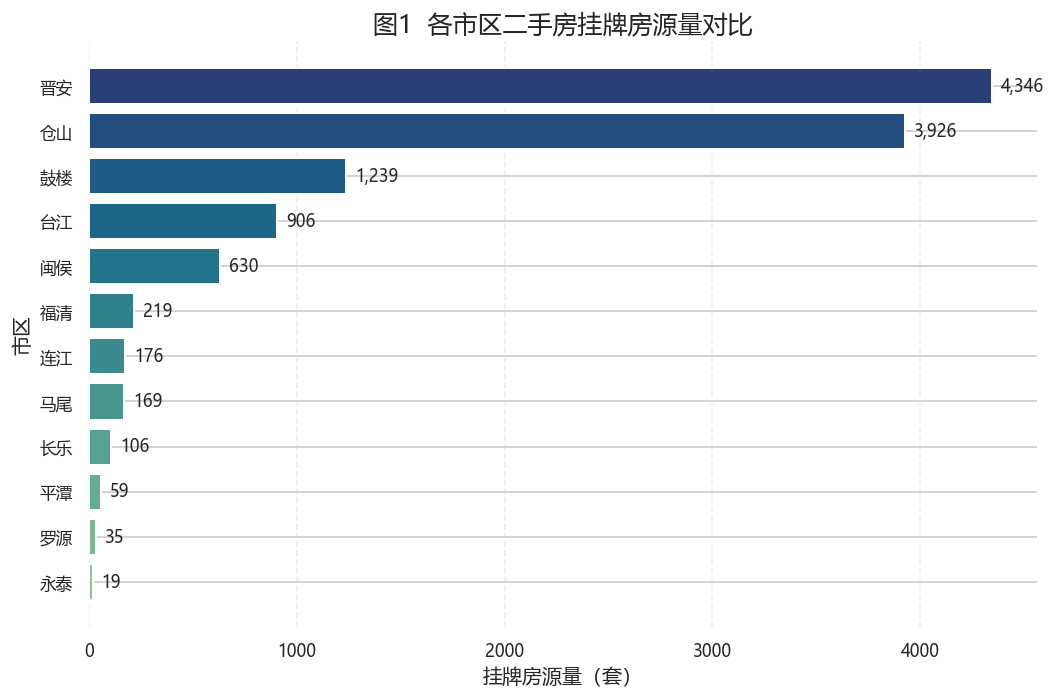

In [55]:
plot1 = district_stats.reset_index().sort_values('房源量', ascending=True)
plt.rcParams["font.family"] = ["Microsoft YaHei"]  # 支持中文
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示方块
fig, ax = plt.subplots(figsize=(9, 6))
colors = sns.color_palette('crest', len(plot1))
ax.barh(plot1['市区'], plot1['房源量'], color=colors, edgecolor='white', linewidth=1.2)
for i, v in enumerate(plot1['房源量']):
    ax.text(v + max(plot1['房源量']) * 0.01, i, f'{v:,}', va='center', fontsize=10)
ax.set_title('图1  各市区二手房挂牌房源量对比')
ax.set_xlabel('挂牌房源量（套）')
ax.set_ylabel('市区')
ax.grid(axis='x', linestyle='--', alpha=0.35)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

通过图1，我们可以看到，晋安和仓山的挂牌房源量明显高于其他区域，二者合计占有效样本的约 69.92%。这说明样本中的福州二手房供给具有明显集聚特征，主要集中在城市居住扩展和改善需求较活跃的区域。鼓楼、台江作为传统中心区，房源量不如晋安和仓山，但仍是重要的中心城区样本。相比之下，罗源、永泰、平潭等外围区域房源量较少，在解释这些区域价格时需要注意样本规模较小带来的稳定性问题。

### 图表 2：不同市区的挂牌均价是否存在明显空间梯度

该问题关注的是**价格空间分异**。同样是二手房，中心区、近中心区和外围县市可能因为公共服务、交通、学区、商业配套和就业可达性不同而呈现不同单价水平。

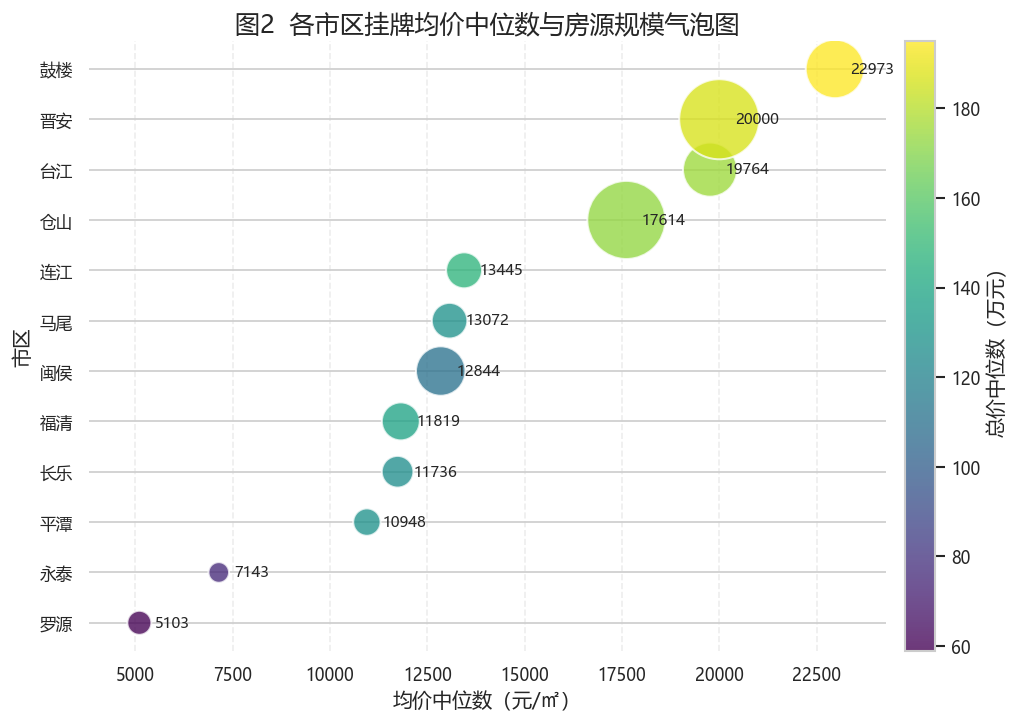

In [56]:
plot2 = district_stats.reset_index().sort_values('均价中位数', ascending=True)
plt.rcParams["font.family"] = ["Microsoft YaHei"]  # 支持中文
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示方块
fig, ax = plt.subplots(figsize=(9, 6.2))
sc = ax.scatter(
    plot2['均价中位数'], plot2['市区'],
    s=np.sqrt(plot2['房源量']) * 35,
    c=plot2['总价中位数'],
    cmap='viridis',
    alpha=0.78,
    edgecolor='white',
    linewidth=1.2
)
for _, row in plot2.iterrows():
    ax.text(row['均价中位数'] + 400, row['市区'], f"{row['均价中位数']:.0f}", va='center', fontsize=9)
cb = plt.colorbar(sc, ax=ax, pad=0.02)
cb.set_label('总价中位数（万元）')
ax.set_title('图2  各市区挂牌均价中位数与房源规模气泡图')
ax.set_xlabel('均价中位数（元/㎡）')
ax.set_ylabel('市区')
# 扩充x轴左右边界，防止气泡左右截断
x_min = plot2['均价中位数'].min()
x_max = plot2['均价中位数'].max()
ax.set_xlim(x_min - 1300, x_max + 1300)
ax.grid(axis='x', linestyle='--', alpha=0.35)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

图2说明鼓楼的均价中位数最高，达到约 22973 元/㎡；晋安和台江也处于较高水平，分别约为 20000 元/㎡和 19763.5 元/㎡。仓山房源量很大，但均价中位数低于鼓楼、晋安、台江，说明其更多表现为大规模居住供给区域，而非最高价格区。罗源、永泰等外围区域均价明显偏低。最高区域与最低区域之间的均价中位数差距约为 4.50 倍，说明福州二手房挂牌市场存在显著空间价格梯度。

### 图表 3：福州二手房挂牌单价整体呈现的分布形态

该问题关注的是**价格分布结构**。如果均价分布右偏，则说明多数房源处于中等价格区间，少量高价房源会抬高平均值，此时中位数比均值更能代表典型水平。

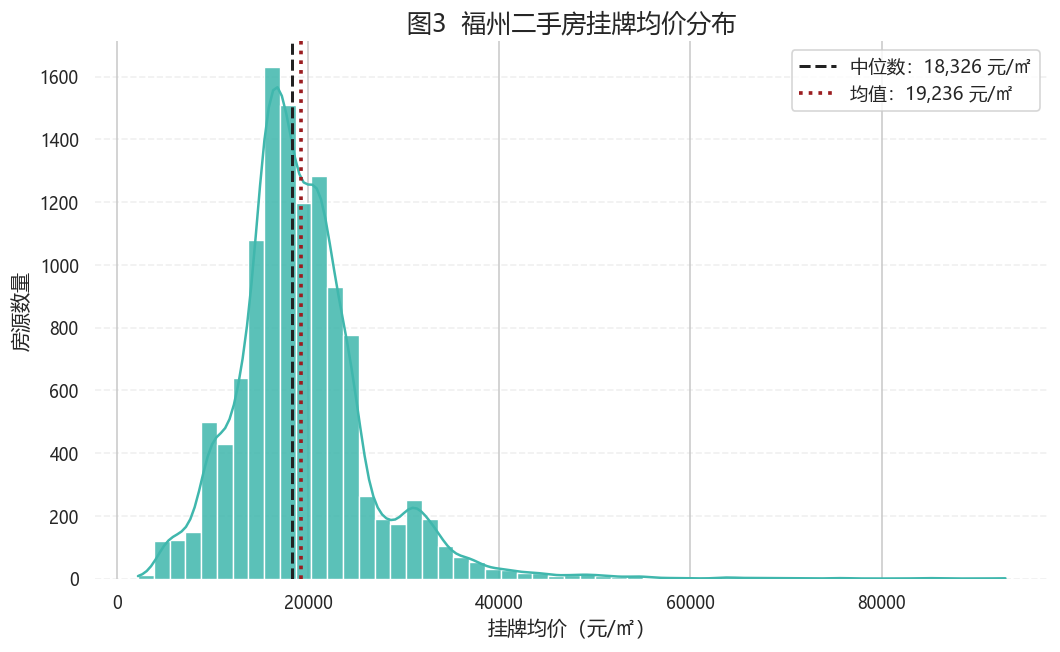

In [83]:
fig, ax = plt.subplots(figsize=(9, 5.6))
sns.histplot(df_clean['均价_元每㎡'], bins=55, kde=True, color=sns.color_palette('mako')[4], edgecolor='white', alpha=0.86, ax=ax)
median_price = df_clean['均价_元每㎡'].median()
mean_price = df_clean['均价_元每㎡'].mean()
ax.axvline(median_price, color='#222222', linestyle='--', linewidth=1.8, label=f'中位数：{median_price:,.0f} 元/㎡')
ax.axvline(mean_price, color='#9b1d20', linestyle=':', linewidth=2.2, label=f'均值：{mean_price:,.0f} 元/㎡')
ax.set_title('图3  福州二手房挂牌均价分布')
ax.set_xlabel('挂牌均价（元/㎡）')
ax.set_ylabel('房源数量')
ax.legend(frameon=True)
ax.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

从图3可以看到，均价分布呈明显右偏特征，主体房源集中在约 1.5 万—2.5 万元/㎡区间。均价均值约为 19235.6 元/㎡，高于中位数 18325.5 元/㎡，说明少量高单价房源抬高了平均值。因此，在描述市场典型价格水平时，中位数比均值更稳健；在比较区域或房龄差异时，本报告也优先使用中位数来降低极端高价房源的影响。

### 图表 4：面积增加是否必然带来总价同比例上升

该问题关注的是**面积—总价关系**。理论上面积越大，总价越高，但如果同面积房源之间总价差异很大，就说明区位、品质、房龄、户型和单价差异也在共同发挥作用。

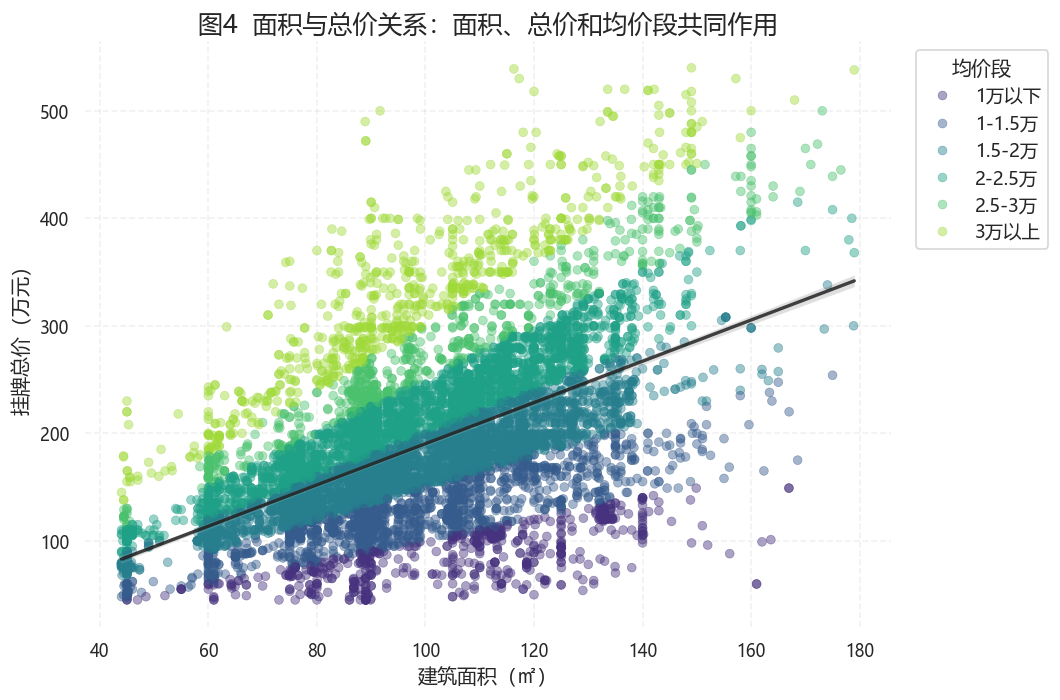

In [17]:
# 为保证主体样本可读性，仅在图形展示时截取 1%—99% 分位数范围；并未删除原始数据。
x_low, x_high = df_clean['面积_㎡'].quantile([0.01, 0.99])
y_low, y_high = df_clean['总价_万元'].quantile([0.01, 0.99])
plot4 = df_clean[(df_clean['面积_㎡'].between(x_low, x_high)) & (df_clean['总价_万元'].between(y_low, y_high))].copy()
plt.rcParams["font.family"] = ["Microsoft YaHei"]  # 支持中文
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示方块
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=plot4,
    x='面积_㎡', y='总价_万元',
    hue='均价段',
    palette='viridis',
    alpha=0.45,
    s=28,
    edgecolor=None,
    ax=ax
)
sns.regplot(data=plot4, x='面积_㎡', y='总价_万元', scatter=False, color='#222222', line_kws={'linewidth': 2, 'alpha': 0.85}, ax=ax)
ax.set_title('图4  面积与总价关系：面积、总价和均价段共同作用')
ax.set_xlabel('建筑面积（㎡）')
ax.set_ylabel('挂牌总价（万元）')
ax.legend(title='均价段', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
ax.grid(True, linestyle='--', alpha=0.28)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

通过图4，我们发现，面积与总价整体呈正相关，说明建筑面积仍是决定总价的重要基础变量。但散点并没有严格贴合一条直线，同等面积房源之间存在明显总价差异，且高均价段房源在相同面积下往往处于更高总价位置。这说明总价不是面积的简单倍数，而是面积、区位单价、房屋品质和市场定位共同作用的结果。Spearman 相关分析显示，面积与总价相关性较强，而均价与总价的相关性也较高，进一步说明“面积规模”和“单位价格”共同决定了总价。

### 图表 5：不同房龄房源的挂牌均价是否存在差异？

该问题关注的是**时间属性与价格关系**。通常认为新房龄会带来品质溢价，但二手房价格还受到区位影响。如果较老房源位于核心区，它们可能仍保持较高单价。

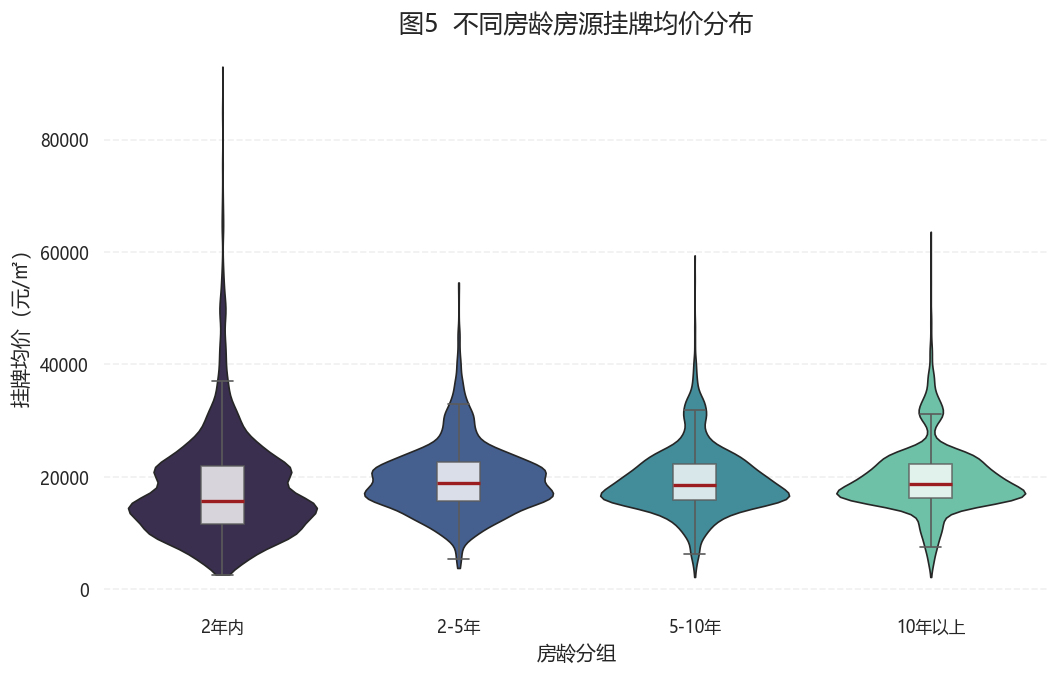

In [18]:
age_order = ['2年内', '2-5年', '5-10年', '10年以上']
fig, ax = plt.subplots(figsize=(9, 5.8))
plt.rcParams["font.family"] = ["Microsoft YaHei"]  # 支持中文
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示方块
sns.violinplot(
    data=df_clean,
    x='房龄', y='均价_元每㎡',
    order=age_order,
    palette='mako',
    inner=None,
    cut=0,
    linewidth=1,
    ax=ax
)
sns.boxplot(
    data=df_clean,
    x='房龄', y='均价_元每㎡',
    order=age_order,
    width=0.18,
    boxprops={'facecolor': 'white', 'alpha': 0.8},
    medianprops={'color': '#9b1d20', 'linewidth': 2},
    showfliers=False,
    ax=ax
)
ax.set_title('图5  不同房龄房源挂牌均价分布')
ax.set_xlabel('房龄分组')
ax.set_ylabel('挂牌均价（元/㎡）')
ax.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

图5显示，不同房龄组的价格差异并不是“越新越贵”的单调关系。2 年内房源的均价中位数约为 15773 元/㎡，低于 2—5 年、5—10 年和 10 年以上房源。这一现象说明，房龄本身并不是决定价格的唯一因素：较新的房源可能更多位于外围新开发板块，价格受区位影响而偏低；而较老房源如果位于鼓楼、台江等中心城区，则可能因配套成熟、交通便利、学区和商业资源较好而保持较高单价。

### 图表 6：不同户型在面积、总价和单价上呈现的市场定位

该问题关注的是**户型结构与市场定位**。户型不仅影响居住功能，也通常对应不同面积段和不同总价门槛，因此可用于识别刚需、改善和高端改善房源。

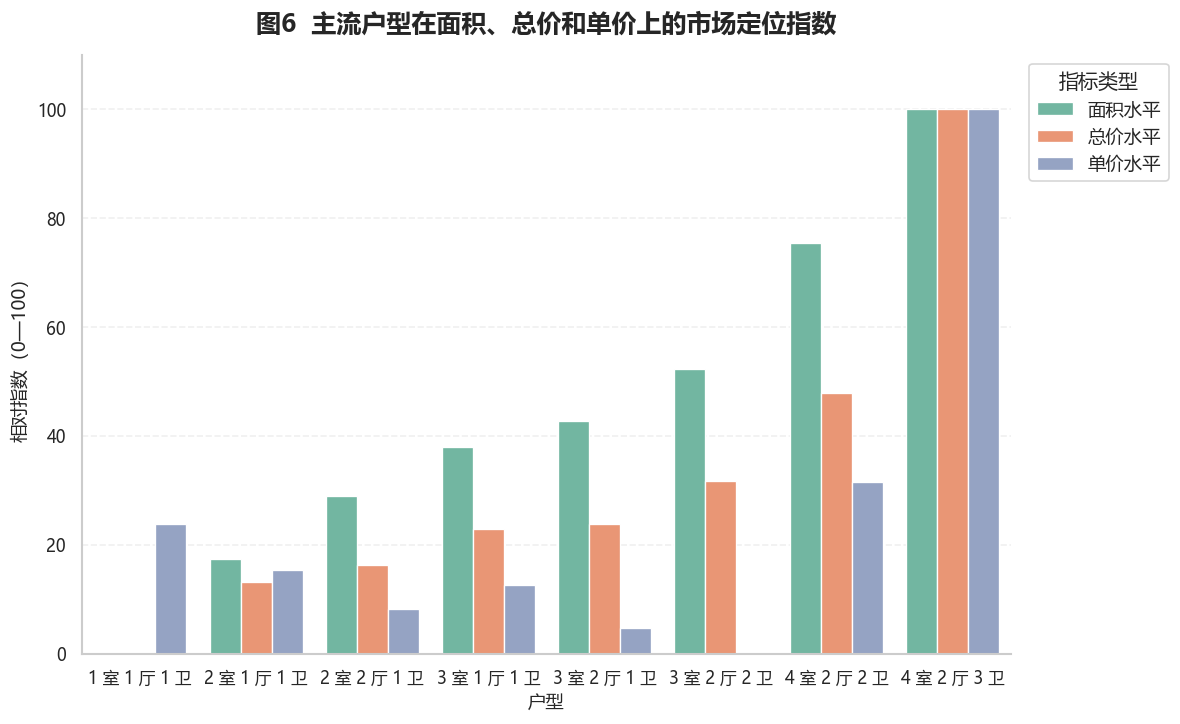

In [68]:
if 'df_price' not in globals():

    if 'df_clean' not in globals():
        DATA_PATH = Path('ershoufang_list.csv')
        if not DATA_PATH.exists():
            DATA_PATH = Path('/mnt/data/ershoufang_list.csv')

        df_raw = pd.read_csv(DATA_PATH, encoding='utf-8-sig')
        df_clean = df_raw.copy()

        for col in df_clean.select_dtypes(include='object').columns:
            df_clean[col] = (
                df_clean[col]
                .astype(str)
                .str.replace('\n', '', regex=False)
                .str.strip()
            )

    if '面积_㎡' not in df_clean.columns and '面积' in df_clean.columns:
        df_clean['面积_㎡'] = df_clean['面积'].apply(extract_number)

    if '总价_万元' not in df_clean.columns and '总价' in df_clean.columns:
        df_clean['总价_万元'] = df_clean['总价'].apply(extract_number)

    if '均价_元每㎡' not in df_clean.columns and '均价' in df_clean.columns:
        df_clean['均价_元每㎡'] = df_clean['均价'].apply(extract_number)

    valid_mask = (
        df_clean['面积_㎡'].notna() &
        df_clean['总价_万元'].notna() &
        df_clean['均价_元每㎡'].notna() &
        (df_clean['面积_㎡'] > 0) &
        (df_clean['总价_万元'] > 0) &
        (df_clean['均价_元每㎡'] > 0)
    )

    df_price = df_clean.loc[valid_mask].copy()

# ========= 统计主流户型 =========
layout_stats = (
    df_price
    .dropna(subset=['户型'])
    .groupby('户型')
    .agg(
        房源量=('户型', 'size'),
        面积中位数=('面积_㎡', 'median'),
        总价中位数=('总价_万元', 'median'),
        均价中位数=('均价_元每㎡', 'median')
    )
    .sort_values('房源量', ascending=False)
    .head(8)
    .reset_index()
)

# 按面积中位数排序，使户型结构从小到大更有层次
layout_stats = layout_stats.sort_values('面积中位数')

# ========= 将不同单位的指标转为 0-100 相对指数 =========
index_cols = ['面积中位数', '总价中位数', '均价中位数']

layout_index = layout_stats[['户型'] + index_cols].copy()

for col in index_cols:
    min_value = layout_index[col].min()
    max_value = layout_index[col].max()
    layout_index[col + '指数'] = (
        (layout_index[col] - min_value) / (max_value - min_value) * 100
    )

plot_data = layout_index.melt(
    id_vars='户型',
    value_vars=['面积中位数指数', '总价中位数指数', '均价中位数指数'],
    var_name='指标',
    value_name='相对指数'
)

plot_data['指标'] = plot_data['指标'].replace({
    '面积中位数指数': '面积水平',
    '总价中位数指数': '总价水平',
    '均价中位数指数': '单价水平'
})

# ========= 绘图 =========
fig, ax = plt.subplots(figsize=(10, 6.2))

sns.barplot(
    data=plot_data,
    x='户型',
    y='相对指数',
    hue='指标',
    palette='Set2',
    edgecolor='white',
    linewidth=0.8,
    ax=ax
)

ax.set_title(
    '图6  主流户型在面积、总价和单价上的市场定位指数',
    fontsize=15,
    pad=14,
    fontweight='bold'
)

ax.set_xlabel('户型', fontsize=11)
ax.set_ylabel('相对指数（0—100）', fontsize=11)
ax.set_ylim(0, 110)

ax.legend(
    title='指标类型',
    frameon=True,
    loc='upper left',
    bbox_to_anchor=(1.01, 1)
)

ax.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine()

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

从图6中，我们看到，二手房数据中最常见的户型是3室2厅2卫、4室2厅2卫、3室2厅1卫和2室2厅1卫。3室户型处于主流改善和刚需改善之间，总价中位数较为适中；4室尤其是带3卫的户型面积和总价明显更高，市场定位更偏改善或高端改善；1室和2室户型面积较小，总价门槛较低，但部分小户型单价并不低，说明小面积房源可能受到地段便利性和低总价门槛的共同影响。

### 图表 7：低层、中层和高层房源的挂牌均价是否存在楼层差异

该问题关注的是**楼层位置与价格差异**。在高层住宅市场中，中高楼层可能因采光、视野、通风等因素获得一定溢价，但这种差异也可能被区位和产品类型稀释。

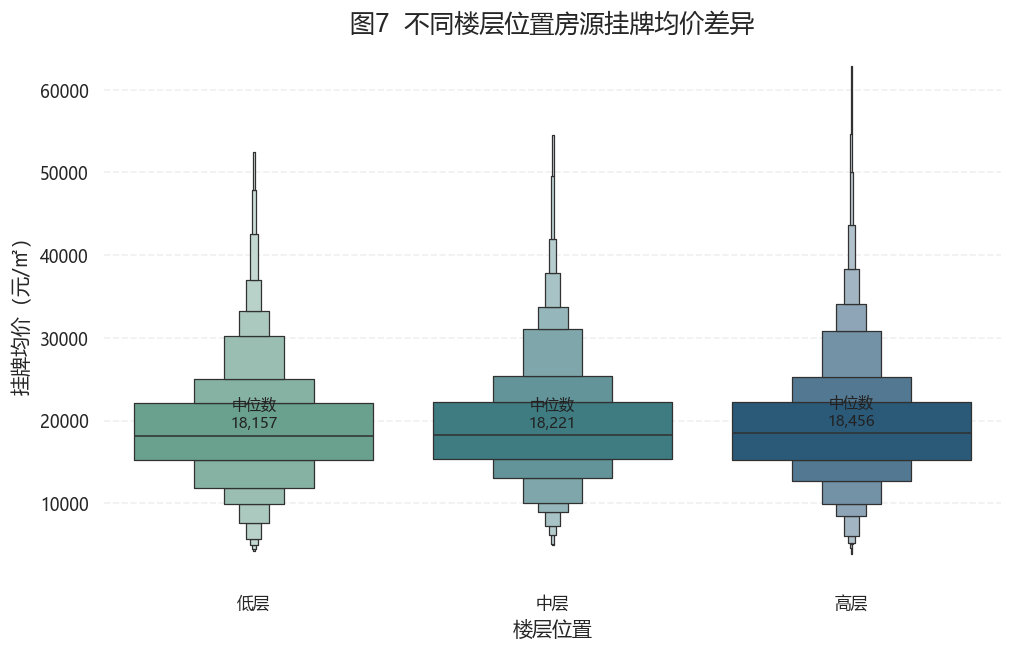

In [21]:
floor_order = ['低层', '中层', '高层']
plot7 = df_clean[df_clean['楼层位置'].isin(floor_order)].copy()
plt.rcParams["font.family"] = ["Microsoft YaHei"]  # 支持中文
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示方块
fig, ax = plt.subplots(figsize=(8.6, 5.6))
sns.boxenplot(
    data=plot7,
    x='楼层位置', y='均价_元每㎡',
    order=floor_order,
    palette='crest',
    showfliers=False,
    ax=ax
)
median_floor = plot7.groupby('楼层位置')['均价_元每㎡'].median().reindex(floor_order)
for i, v in enumerate(median_floor):
    ax.text(i, v + 500, f'中位数\n{v:,.0f}', ha='center', va='bottom', fontsize=9, color='#222222')
ax.set_title('图7  不同楼层位置房源挂牌均价差异')
ax.set_xlabel('楼层位置')
ax.set_ylabel('挂牌均价（元/㎡）')
ax.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

图7中，从中位数看，高层房源均价略高于中层和低层，但三类楼层之间差距并不大。低层、中层和高层的均价中位数分别约为 18157 元/㎡、18221 元/㎡和 18456 元/㎡。这说明楼层位置可能存在轻微价格差异，但在本数据中并不是最强的价格解释变量。与行政区差异相比，楼层差异更小，表明二手房定价中区位因素可能比楼层因素更重要。

### 图表 8：面积段与总价段共同构成的福州二手房市场层级

该问题关注的是**市场层级结构**。通过面积段与总价段交叉，可以识别哪些组合是市场主体，哪些组合属于低总价小户型或高总价改善型房源。

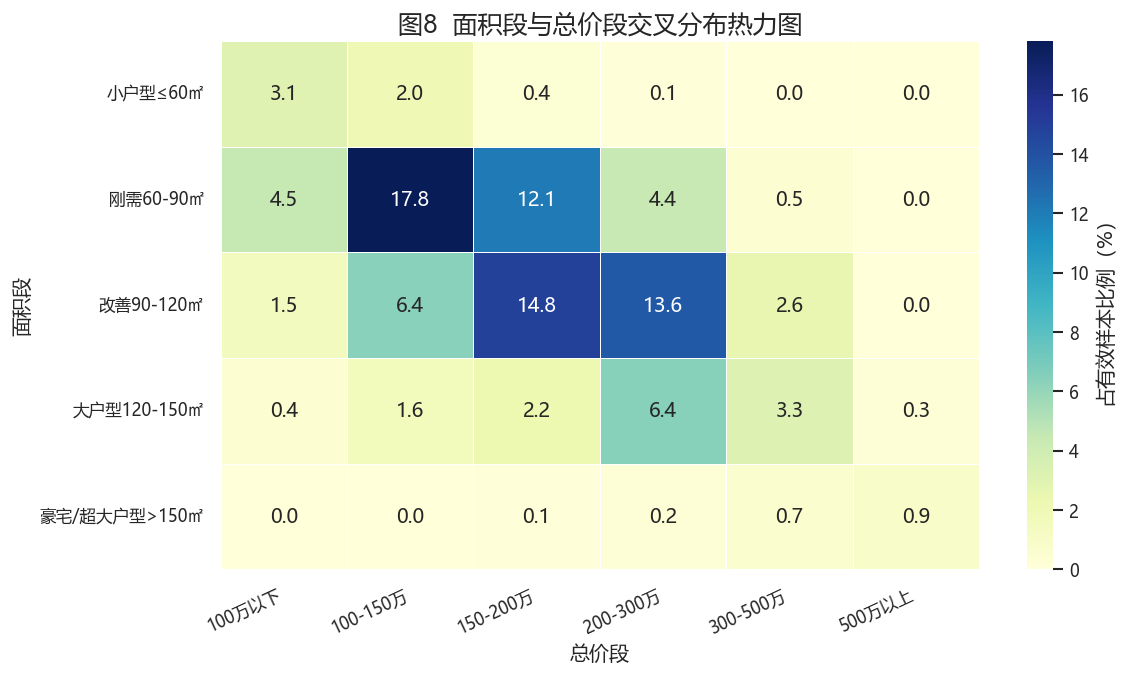

In [22]:
cross = pd.crosstab(df_clean['面积段'], df_clean['总价段'])
cross_pct = cross.div(cross.sum().sum()) * 100
plt.rcParams["font.family"] = ["Microsoft YaHei"]  # 支持中文
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示方块
fig, ax = plt.subplots(figsize=(10, 5.8))
sns.heatmap(
    cross_pct,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    linewidths=0.6,
    linecolor='white',
    cbar_kws={'label': '占有效样本比例（%）'},
    ax=ax
)
ax.set_title('图8  面积段与总价段交叉分布热力图')
ax.set_xlabel('总价段')
ax.set_ylabel('面积段')
plt.xticks(rotation=25, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

 热力图显示，福州二手房挂牌市场的主体集中在 60—120㎡面积段以及 100—300 万总价段。其中，60—90㎡更接近刚需市场，90—120㎡对应改善需求最密集的面积区间；120—150㎡以及 150㎡以上房源数量较少，但总价明显上移，尤其 150㎡以上房源更容易进入 300 万以上甚至 500 万以上区间。由此可见，福州二手房市场不是单一价格市场，而是由低总价小户型、主流刚需、改善型和高端改善型多个层级共同构成。

## 8. 统计验证与综合讨论

为了避免只依赖图形直观判断，本节结合分组统计和相关分析，对前文发现进行进一步验证。重点关注三个方面：区域集中度、价格差异幅度、面积与价格关系。

### 8.1统计验证

In [23]:
# 区域集中度和价格差异
concentration_top2 = district_stats['房源量'].head(2).sum() / len(df_clean)
concentration_top4 = district_stats['房源量'].head(4).sum() / len(df_clean)
price_gap = district_stats['均价中位数'].max() / district_stats['均价中位数'].min()

# Spearman 相关更适合非正态和右偏数据
corr_vars = df_clean[['面积_㎡', '总价_万元', '均价_元每㎡', '建造年份', '室', '总楼层']].corr(method='spearman')

summary_table = pd.DataFrame({
    '统计指标': ['晋安+仓山房源占比', '前四大供给市区房源占比', '最高/最低市区均价中位数倍数', '面积与总价 Spearman相关', '均价与总价 Spearman相关', '面积与均价 Spearman相关'],
    '数值': [
        f'{concentration_top2*100:.2f}%',
        f'{concentration_top4*100:.2f}%',
        f'{price_gap:.2f} 倍',
        f"{corr_vars.loc['面积_㎡', '总价_万元']:.3f}",
        f"{corr_vars.loc['均价_元每㎡', '总价_万元']:.3f}",
        f"{corr_vars.loc['面积_㎡', '均价_元每㎡']:.3f}"
    ]
})
display(summary_table)

display(corr_vars.round(3))

,统计指标,数值
0,晋安+仓山房源占比,69.92%
1,前四大供给市区房源占比,88.06%
2,最高/最低市区均价中位数倍数,4.50 倍
3,面积与总价 Spearman相关,0.583
4,均价与总价 Spearman相关,0.786
5,面积与均价 Spearman相关,0.044


,面积_㎡,总价_万元,均价_元每㎡,建造年份,室,总楼层
面积_㎡,1.00,0.58,0.04,-0.01,0.76,-0.02
总价_万元,0.58,1.00,0.79,-0.14,0.49,-0.02
均价_元每㎡,0.04,0.79,1.00,-0.12,0.06,-0.00
建造年份,-0.01,-0.14,-0.12,1.00,0.12,0.09
室,0.76,0.49,0.06,0.12,1.00,-0.09
总楼层,-0.02,-0.02,-0.00,0.09,-0.09,1.00


### 8.2 综合讨论

第一，样本中的供给集中度较高。晋安和仓山两个区域合计占有效样本约 69.92%，前四个供给区域合计占比约 88.06%。这说明挂牌房源并不是在所有市区之间均匀分布，而是高度集中于少数居住功能较强、开发规模较大的区域。由此推断，样本所反映的福州二手房市场更偏向主城区和近主城区居住板块。

第二，价格空间分异显著。鼓楼、晋安、台江的均价中位数明显高于外围县市，最高与最低区域的均价中位数相差约 4.50 倍。这种差距说明，福州二手房价格并不仅由房屋面积或房龄决定，更与城市空间资源密切相关。中心城区的教育、医疗、商业、交通和就业可达性更强，可能形成持续的区位溢价。

第三，面积与总价之间存在较强正相关，但面积与均价之间的相关性较弱。这意味着面积主要通过“规模效应”影响总价，而单价更多受区位、配套、物业品质和稀缺性影响。换言之，大房子总价通常更高，但大房子不一定单价更高；真正影响单价的关键可能是区域资源和产品定位。

第四，房龄差异需要结合区位解释。2 年内房源的均价中位数低于其他房龄组，表明“新”并不必然对应“贵”。如果新增供应更多分布在外围板块，其价格可能低于中心区老房源。因此，在二手房分析中，不能只根据房龄判断价格高低，而应把房龄与区位、面积、户型共同纳入解释框架。

## 9. 主要结论

基于上述清洗、统计与可视化分析，本报告得到以下结论：

1. **福州二手房挂牌供给具有明显区域集中性。** 晋安和仓山是样本中挂牌房源最集中的区域，二者合计约占有效样本的七成，说明福州二手房供给主要集中于居住规模较大和开发活跃的区域。

2. **区域价格梯度显著，中心区具有明显单价优势。** 鼓楼的均价中位数最高，晋安和台江也处于较高水平；罗源、永泰等外围区域均价较低。区域之间价格差异明显，说明城市空间资源对二手房单价影响较强。

3. **挂牌均价呈右偏分布，中位数比均值更能代表典型水平。** 少量高单价房源会抬高均值，因此使用中位数进行区域比较和房龄比较更稳健。

4. **面积显著影响总价，但不等于决定单价。** 面积与总价之间存在较强正相关，但面积与均价相关性较弱，说明总价由面积和单价共同决定，而单价更依赖区位、资源和产品属性。

5. **房龄与价格之间不是简单的线性关系。** 2 年内房源单价中位数较低，说明新房源可能更多位于外围新区；中心区老房源可能因配套成熟而保持价格优势。

6. **主流市场集中在 60—120㎡和 100—300 万元区间。** 60—90㎡对应刚需市场，90—120㎡对应改善型主流市场；150㎡以上房源占比较小，但价格层级明显上移，体现高端改善特征。

7. **楼层位置的价格差异相对有限。** 高层均价中位数略高，但低层、中层、高层之间差距远小于市区之间差距，说明楼层因素在本数据中不是最主要的价格分异来源。

总体而言，福州二手房挂牌市场呈现出“供给集中、价格分层、中心区溢价、主流面积段突出”的结构特征。对于购房者而言，若关注总价控制，应重点比较 60—90㎡和 90—120㎡房源在不同区域之间的价格差异；若关注保值和资源配套，则需要更加重视区域位置和成熟度。对于市场研究而言，后续可进一步引入地铁距离、学区、商圈、物业类型和成交价格等变量，从挂牌市场分析拓展到真实成交市场分析。

## 10. 本报告的不足与改进方向

本报告基于挂牌房源数据展开分析，能够反映市场供给端和挂牌价格结构，但仍存在一定局限：

1. **挂牌价格不等于成交价格。** 房东报价可能存在议价空间，因此挂牌价格只能代表市场预期，不完全等同于真实成交价格。
2. **缺少空间坐标。** 数据中没有经纬度，无法直接计算到地铁、学校、医院和商圈的距离，因此区位解释主要停留在市区层面。
3. **缺少物业品质变量。** 装修、物业、容积率、是否电梯、车位等因素可能影响价格，但当前数据字段不完整。
4. **样本来源可能存在平台偏差。** 数据来自特定平台或抓取渠道，不能完全代表福州所有二手房房源。

如果进一步改进，可以补充成交数据、地铁站点、学校资源和商圈距离等变量，并使用更细粒度的空间可视化或回归模型解释价格形成机制。